# Bridging & Chaining — Interactive Example

This notebook runs the **actual** `_longest_run()` function from `segmentation.py` on a small, fake 14-day example, so you can see exactly how `max_gap` and `max_total_gap` behave — no need to trust a written explanation, just run it and watch.

No repo imports needed — the real function is copied in below so this notebook runs standalone.

## Definitions (read these first)

- **Run:** a stretch of *consecutive* days where the condition is `True` (e.g. "rising").
- **Gap:** a stretch of *consecutive* days between two runs where the condition is `False`.
- **Bridge over a gap:** treat two `True` stretches on either side of a gap as **one continuous run**, ignoring the gap in between. Models a bird pausing briefly without ending its migration.
- **`max_gap`:** the longest a *single* gap is allowed to be and still get bridged. Longer than this, and that gap ends the run for good.
- **`max_total_gap`:** a *separate* cap on the **sum of every gap bridged so far** in the current run. Even if each gap individually qualifies under `max_gap`, once the running total exceeds `max_total_gap`, no more bridging happens.
- **Chaining:** the result of bridging *multiple* gaps back to back — several separate `True` stretches get glued together into one long run, even though they were really shorter stretches with pauses in between.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


def _longest_run(mask, max_gap=0, within=None, max_total_gap=None):
    """
    This is the REAL function from segmentation.py, copied here unchanged,
    so this notebook demonstrates the actual code, not a simplified stand-in.
    """
    if max_total_gap is None:
        max_total_gap = max_gap
    lo, hi = within if within is not None else (0, len(mask) - 1)
    best = None
    run_start = None
    gap = 0
    total_gap = 0
    for i in range(lo, hi + 1):
        val = mask.iloc[i]
        if val:
            if run_start is None:
                run_start = i
                total_gap = 0
            gap = 0
        else:
            if run_start is not None:
                gap += 1
                total_gap += 1
                if gap > max_gap or total_gap > max_total_gap:
                    end = i - gap
                    if best is None or (end - run_start) > (best[1] - best[0]):
                        best = (run_start, end)
                    run_start = None
                    gap = 0
                    total_gap = 0
    if run_start is not None:
        end = hi - gap
        if best is None or (end - run_start) > (best[1] - best[0]):
            best = (run_start, end)
    return best

## The example

14 fake days: `T` = "rising" (bird is migrating), `F` = "not rising" (a pause / gap).

```
Day:    1  2  3  4  5  6  7  8  9  10 11 12 13 14
Value:  T  T  T  F  F  T  T  F  T  T  F  F  T  T
```

There are 3 gaps: **Gap A** (days 4–5, length 2), **Gap B** (day 8, length 1), **Gap C** (days 11–12, length 2).

In [2]:
days = list(range(1, 15))
values = [True, True, True, False, False, True, True, False, True, True, False, False, True, True]
mask = pd.Series(values)

for d, v in zip(days, values):
    print(f"Day {d:2}: {'T' if v else 'F'}")

Day  1: T
Day  2: T
Day  3: T
Day  4: F
Day  5: F
Day  6: T
Day  7: T
Day  8: F
Day  9: T
Day 10: T
Day 11: F
Day 12: F
Day 13: T
Day 14: T


## Try it with `max_gap = 2`, `max_total_gap = 3`

Prediction (see `chaining_and_bridging.md`): Gap A (2) and Gap B (1) get bridged — running total reaches exactly 3, the cap. Gap C (2) would push the total to 5, over the cap — so it does NOT get bridged, and the run stops there.

In [3]:
result = _longest_run(mask, max_gap=2, max_total_gap=3)
start_idx, end_idx = result
print(f"Longest run found: index {start_idx} to {end_idx}")
print(f"In day numbers: Day {days[start_idx]} to Day {days[end_idx]}")
print(f"Run length: {end_idx - start_idx + 1} days")

Longest run found: index 0 to 9
In day numbers: Day 1 to Day 10
Run length: 10 days


You should see: **Day 1 to Day 10** — confirming Gap A and Gap B got bridged (chained together into one run), while Gap C broke the chain, exactly as predicted.

## Visualize it

Green = the winning run (bridged and chained together). Orange = the gaps that got bridged (folded into the green run). Grey = everything outside the winning run (including Gap C, which broke the chain, and the separate short run after it).

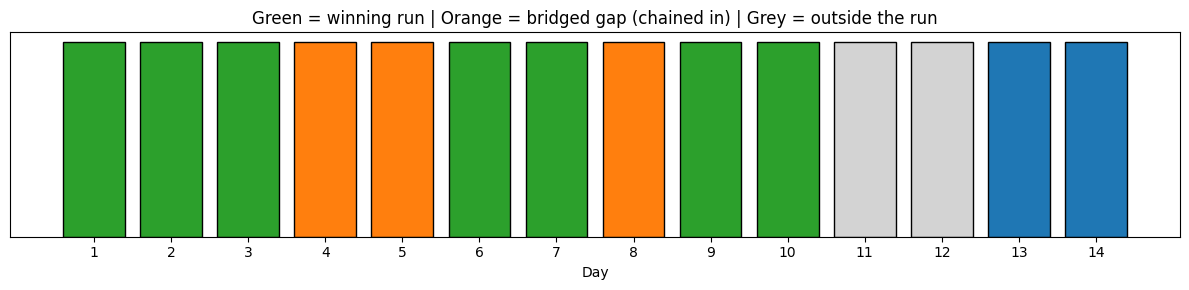

In [4]:
colors = []
for i, v in enumerate(values):
    if start_idx <= i <= end_idx:
        colors.append("tab:green" if v else "tab:orange")  # bridged gap inside the winning run
    else:
        colors.append("tab:blue" if v else "lightgrey")

fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(days, [1] * len(days), color=colors, edgecolor="black")
ax.set_xticks(days)
ax.set_yticks([])
ax.set_xlabel("Day")
ax.set_title("Green = winning run | Orange = bridged gap (chained in) | Grey = outside the run")
plt.tight_layout()
plt.show()

## Try your own numbers

Change `max_gap` and `max_total_gap` below and re-run to see how the result changes. Try `max_gap=1` (Gap A, length 2, should no longer qualify at all) or `max_total_gap=2` (only Gap A gets bridged, Gap B breaks the chain).

In [5]:
# Change these two numbers and re-run this cell
my_max_gap = 1
my_max_total_gap = 2

result2 = _longest_run(mask, max_gap=my_max_gap, max_total_gap=my_max_total_gap)
s2, e2 = result2
print(f"With max_gap={my_max_gap}, max_total_gap={my_max_total_gap}:")
print(f"Longest run: Day {days[s2]} to Day {days[e2]} ({e2 - s2 + 1} days)")

With max_gap=1, max_total_gap=2:
Longest run: Day 6 to Day 10 (5 days)
